# Densities

In [1]:
import sys
sys.path.insert(0, '../../src/')

import numpy as np
import matplotlib.pyplot as plt
import pickle as pkl
import tensorflow as tf


from spectrum import channel_spectrum, complex_spacing_ratio, Spectrum, coat_spectrum, spectrum_to_angular, spectrum_to_radial
from analysis import *

#np.set_printoptions(threshold=sys.maxsize)
np.set_printoptions(precision=4)

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

2025-11-11 15:54:12.496282: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
def save_spectrum(spectrum, filename):
    csr_array = np.real(spectrum.get_spectrum(is_complex=False))
    np.savetxt(filename, csr_array)

def save_heatmap(heatmap, filename):
    n = heatmap.shape[0]
    grid = np.arange(n)
    x, y = np.meshgrid(grid, grid)

    heatmap = heatmap.flatten()
    x = x.flatten()
    y = y.flatten()

    data = np.array([x, y, heatmap]).T
    np.savetxt(filename, data)
    


In [3]:
r_list = []
a_list = []

## Retrieve CSR

### L = 5

2025-11-11 15:54:14.472942: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-11-11 15:54:14.472983: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES="-1"
2025-11-11 15:54:14.472988: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
2025-11-11 15:54:14.472992: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2025-11-11 15:54:14.472996: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: BrigidBrain
2025-11-11 15:54:14.472999: I external/local_xla/xla/stream_executor/cuda/c

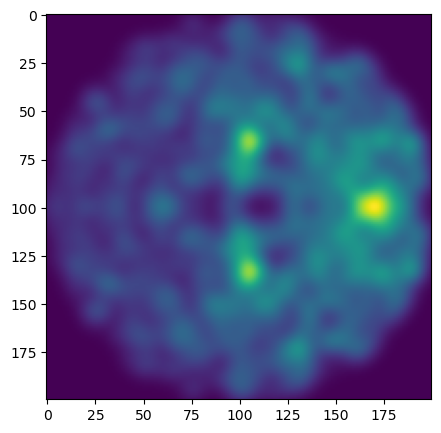

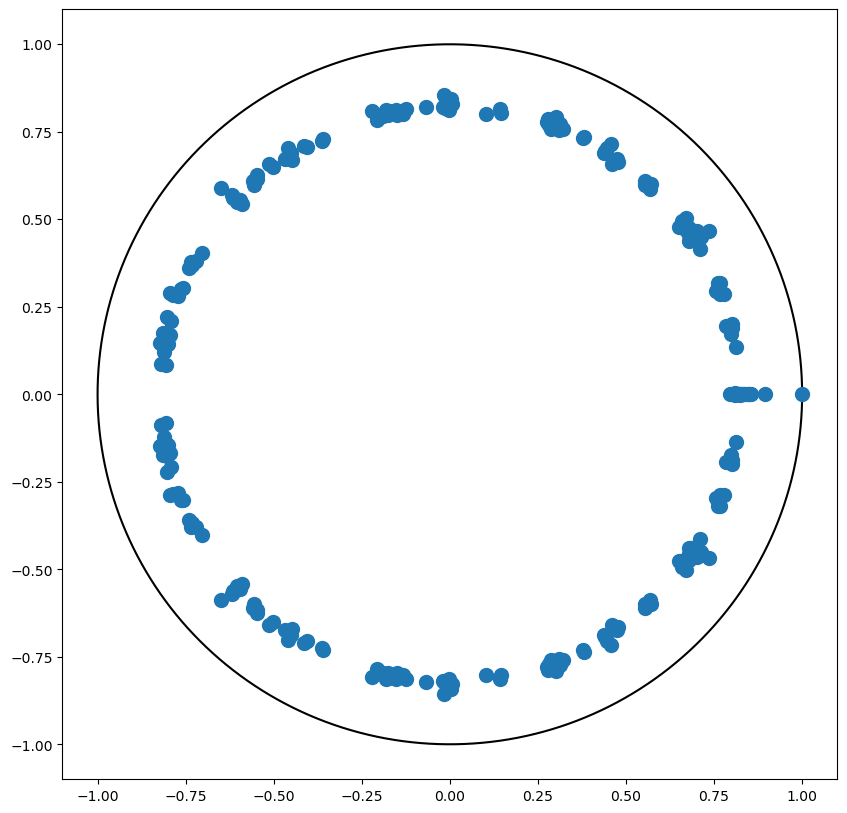

0.6459151622223069 -0.21981035313791877


In [4]:
n = 4

model_list = pkl.load(open(f'models/integrable_baseline_model_{n}_L=5.model', 'rb'))

loss_list = []
spectrum_list = []
csr_integrable_list = []
for model in model_list:
    loss = model.logger.loss_list[0][-1]
    loss_list.append(loss)

    channel = model.channel
    spectrum = channel_spectrum(channel)
    csr = complex_spacing_ratio(spectrum)

    spectrum_list.append(spectrum)
    csr_integrable_list.append(csr)

csr_integrable = Spectrum(csr_integrable_list)
csr_integrable_coat = coat_spectrum(csr_integrable, sigma = 0.05, grid_size = 200)


fig = plt.figure(figsize=(5, 5))
fig.tight_layout()
plt.imshow(csr_integrable_coat)
#plt.savefig('figures/integrable_crs_retrieved_L=5.png')
plt.show()

spectrum_list[0].plot_circle()
spectrum_list[0].plot()
plt.show()


radial = spectrum_to_radial(csr_integrable)
angular = spectrum_to_angular(csr_integrable)

r, a = scatterplot_stats(radial, angular)
print(r, a)
r_list.append(r)
a_list.append(a)


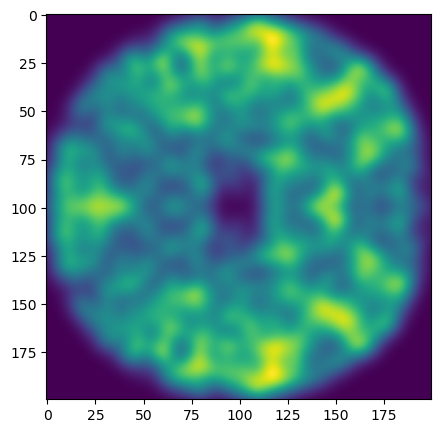

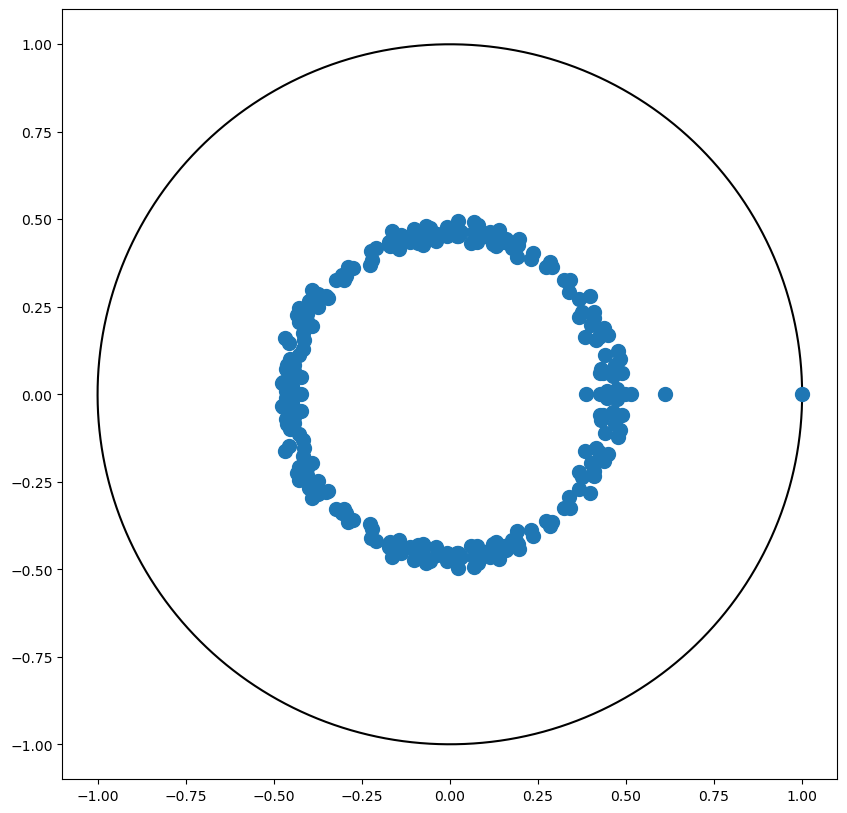

0.7018236972415406 -0.040036042861316415


In [5]:
n = 4

model_list = pkl.load(open(f'models/integrable_baseline_model_{n}_L=20.model', 'rb'))

loss_list = []
spectrum_list = []
csr_integrable_list = []
for model in model_list:
    loss = model.logger.loss_list[0][-1]
    loss_list.append(loss)

    channel = model.channel
    spectrum = channel_spectrum(channel)
    csr = complex_spacing_ratio(spectrum)

    spectrum_list.append(spectrum)
    csr_integrable_list.append(csr)

csr_integrable = Spectrum(csr_integrable_list)
csr_integrable_coat = coat_spectrum(csr_integrable, sigma = 0.05, grid_size = 200)


fig = plt.figure(figsize=(5, 5))
fig.tight_layout()
plt.imshow(csr_integrable_coat)
#plt.savefig('figures/integrable_crs_retrieved_L=5.png')
plt.show()

spectrum_list[0].plot_circle()
spectrum_list[0].plot()
plt.show()


radial = spectrum_to_radial(csr_integrable)
angular = spectrum_to_angular(csr_integrable)

r, a = scatterplot_stats(radial, angular)
print(r, a)
r_list.append(r)
a_list.append(a)

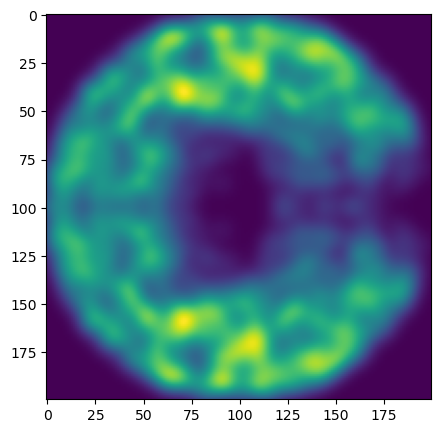

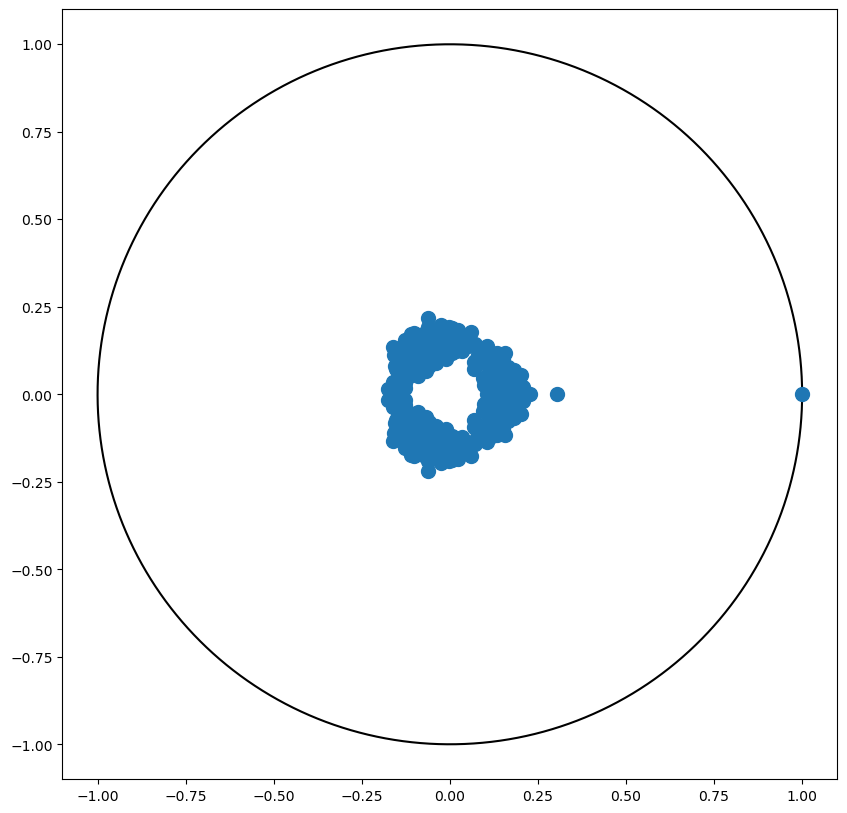

0.7506829074774978 0.0869147381953161


In [6]:
n = 4

model_list = pkl.load(open(f'models/integrable_baseline_model_{n}_L=50.model', 'rb'))

loss_list = []
spectrum_list = []
csr_integrable_list = []
for model in model_list:
    loss = model.logger.loss_list[0][-1]
    loss_list.append(loss)

    channel = model.channel
    spectrum = channel_spectrum(channel)
    csr = complex_spacing_ratio(spectrum)

    spectrum_list.append(spectrum)
    csr_integrable_list.append(csr)

csr_integrable = Spectrum(csr_integrable_list)
csr_integrable_coat = coat_spectrum(csr_integrable, sigma = 0.05, grid_size = 200)


fig = plt.figure(figsize=(5, 5))
fig.tight_layout()
plt.imshow(csr_integrable_coat)
#plt.savefig('figures/integrable_crs_retrieved_L=5.png')
plt.show()

spectrum_list[0].plot_circle()
spectrum_list[0].plot()
plt.show()

radial = spectrum_to_radial(csr_integrable)
angular = spectrum_to_angular(csr_integrable)

r, a = scatterplot_stats(radial, angular)
print(r, a)
r_list.append(r)
a_list.append(a)

In [7]:
saver([r_list, a_list], "data/integrable_scatter_baseline.pkl")

## Intermediate

In [8]:
r_list = []
a_list = []

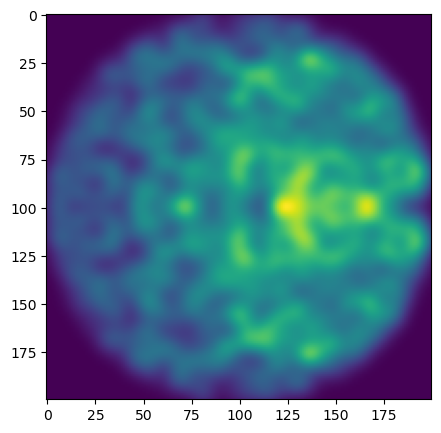

0.6300724522055469 -0.16402264824772866


In [9]:
n = 4

model_list = pkl.load(open(f'models/integrable_intermediate_model_{n}_L=5.model', 'rb'))

loss_list = []
spectrum_list = []
csr_integrable_list = []
for model in model_list:
    loss = model.logger.loss_list[0][-1]
    loss_list.append(loss)

    channel = model.channel
    spectrum = channel_spectrum(channel)
    csr = complex_spacing_ratio(spectrum)

    spectrum_list.append(spectrum)
    csr_integrable_list.append(csr)

csr_integrable = Spectrum(csr_integrable_list)
csr_integrable_coat = coat_spectrum(csr_integrable, sigma = 0.05, grid_size = 200)


fig = plt.figure(figsize=(5, 5))
fig.tight_layout()
plt.imshow(csr_integrable_coat)
#plt.savefig('figures/integrable_crs_retrieved_L=5.png')
plt.show()

radial = spectrum_to_radial(csr_integrable)
angular = spectrum_to_angular(csr_integrable)

r, a = scatterplot_stats(radial, angular)
print(r, a)
r_list.append(r)
a_list.append(a)


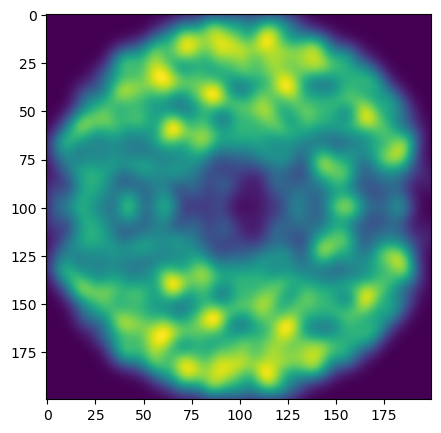

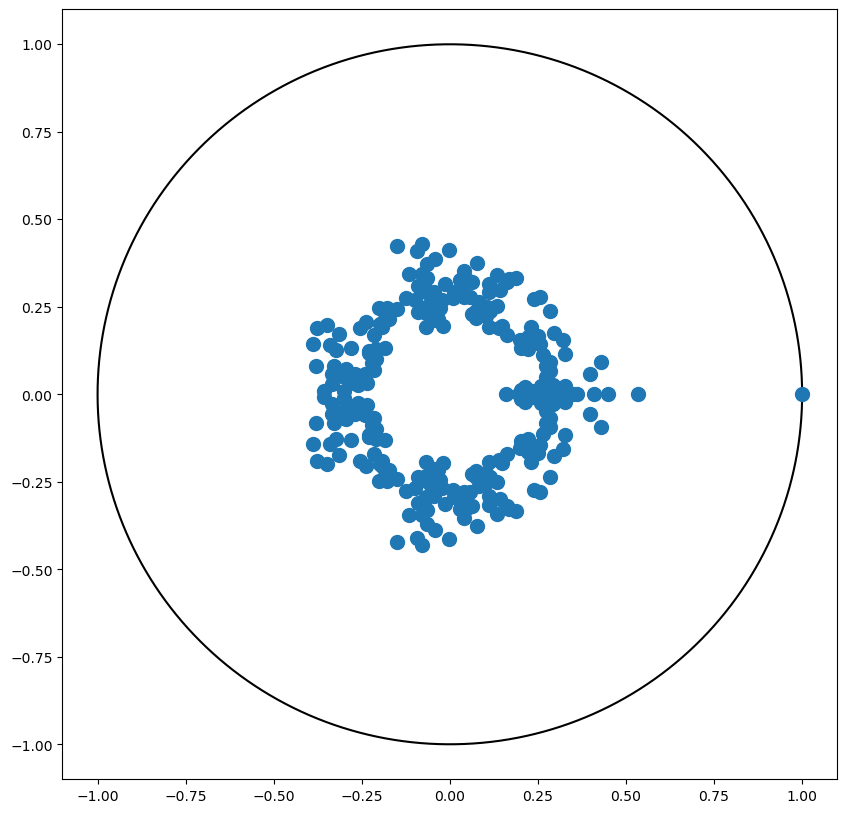

0.7042723435242628 0.009510872068796106


In [10]:
n = 4

model_list = pkl.load(open(f'models/integrable_intermediate_model_{n}_L=20.model', 'rb'))

loss_list = []
spectrum_list = []
csr_integrable_list = []
for model in model_list:
    loss = model.logger.loss_list[0][-1]
    loss_list.append(loss)

    channel = model.channel
    spectrum = channel_spectrum(channel)
    csr = complex_spacing_ratio(spectrum)

    spectrum_list.append(spectrum)
    csr_integrable_list.append(csr)

csr_integrable = Spectrum(csr_integrable_list)
csr_integrable_coat = coat_spectrum(csr_integrable, sigma = 0.05, grid_size = 200)


fig = plt.figure(figsize=(5, 5))
fig.tight_layout()
plt.imshow(csr_integrable_coat)
#plt.savefig('figures/integrable_crs_retrieved_L=5.png')
plt.show()

spectrum_list[0].plot_circle()
spectrum_list[0].plot()
plt.show()

radial = spectrum_to_radial(csr_integrable)
angular = spectrum_to_angular(csr_integrable)

r, a = scatterplot_stats(radial, angular)
print(r, a)
r_list.append(r)
a_list.append(a)


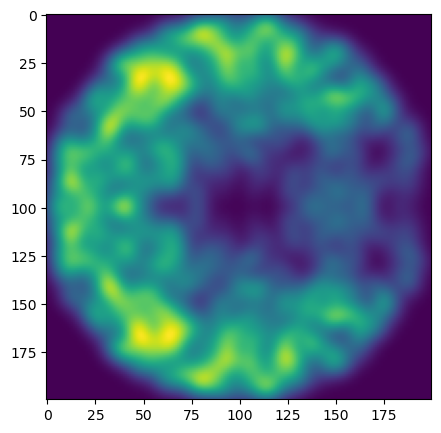

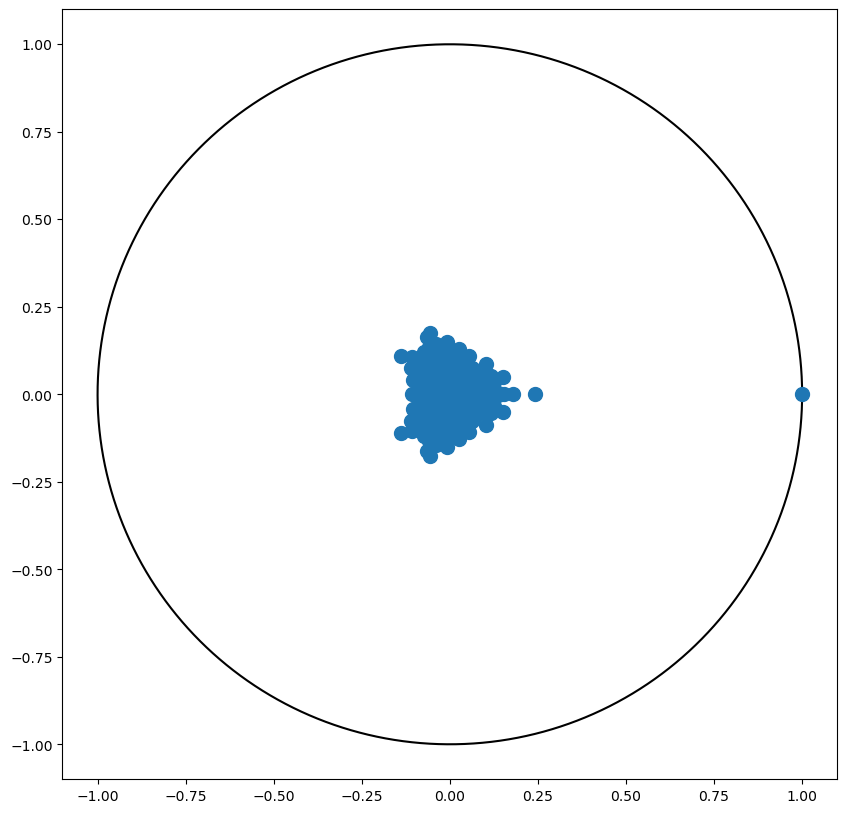

0.7323748759335834 0.16478990626842294


In [11]:
n = 4

model_list = pkl.load(open(f'models/integrable_intermediate_model_{n}_L=50.model', 'rb'))

loss_list = []
spectrum_list = []
csr_integrable_list = []
for model in model_list:
    loss = model.logger.loss_list[0][-1]
    loss_list.append(loss)

    channel = model.channel
    spectrum = channel_spectrum(channel)
    csr = complex_spacing_ratio(spectrum)

    spectrum_list.append(spectrum)
    csr_integrable_list.append(csr)

csr_integrable = Spectrum(csr_integrable_list)
csr_integrable_coat = coat_spectrum(csr_integrable, sigma = 0.05, grid_size = 200)


fig = plt.figure(figsize=(5, 5))
fig.tight_layout()
plt.imshow(csr_integrable_coat)
#plt.savefig('figures/integrable_crs_retrieved_L=5.png')
plt.show()

spectrum_list[0].plot_circle()
spectrum_list[0].plot()
plt.show()

radial = spectrum_to_radial(csr_integrable)
angular = spectrum_to_angular(csr_integrable)

r, a = scatterplot_stats(radial, angular)
print(r, a)
r_list.append(r)
a_list.append(a)


In [12]:
saver([r_list, a_list], "data/integrable_scatter_intermediate.pkl")

## Non-Integratable T = 5

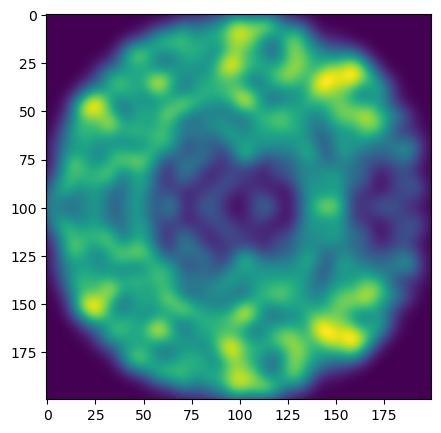

In [13]:
n = 4

model_list = pkl.load(open(f'models/nonintegrable_model_{n}_L=5.model', 'rb'))

loss_list = []
spectrum_list = []
csr_integrable_list = []
for model in model_list:
    loss = model.logger.loss_list[0][-1]
    loss_list.append(loss)

    channel = model.channel
    spectrum = channel_spectrum(channel)
    csr = complex_spacing_ratio(spectrum)

    spectrum_list.append(spectrum)
    csr_integrable_list.append(csr)

csr_integrable = Spectrum(csr_integrable_list)
csr_integrable_coat = coat_spectrum(csr_integrable, sigma = 0.05, grid_size = 200)


fig = plt.figure(figsize=(5, 5))
fig.tight_layout()
plt.imshow(csr_integrable_coat)
#plt.savefig('figures/integrable_crs_retrieved_L=5.png')
plt.show()


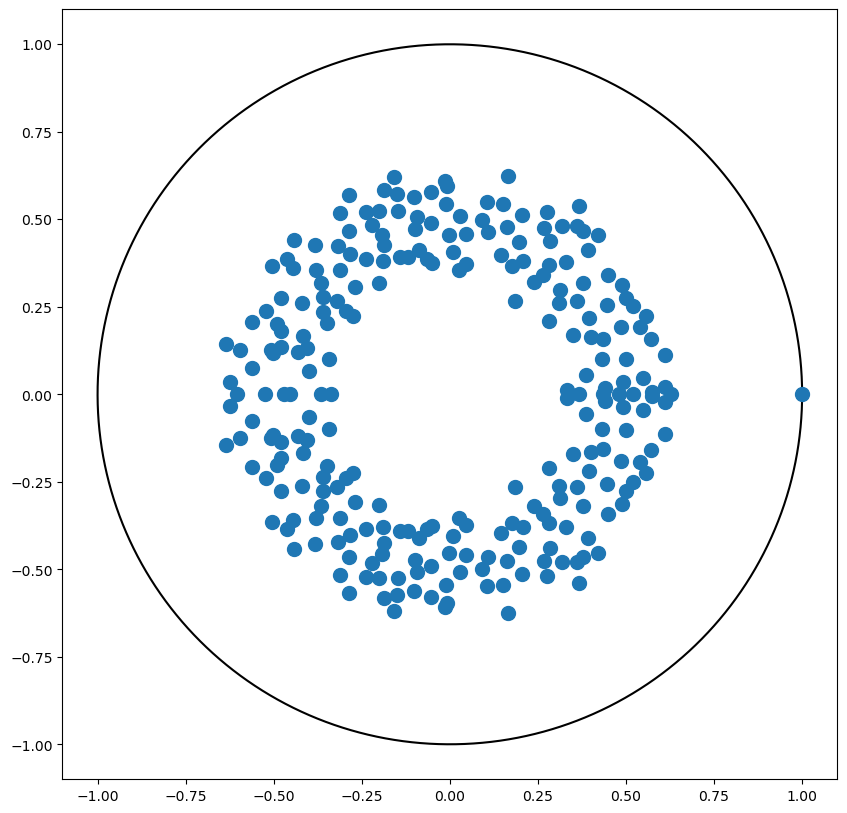

In [14]:
idx = 5
spectrum_list[idx].plot_circle()
spectrum_list[idx].plot()
plt.show()

## Variance

In [15]:
n = 4

model_list = pkl.load(open(f'models/integrable_baseline_model_{n}_L=50.model', 'rb'))

r_list = []
a_list = []
for model in model_list:
    loss = model.logger.loss_list[0][-1]
    loss_list.append(loss)

    channel = model.channel
    spectrum = channel_spectrum(channel)
    csr = complex_spacing_ratio(spectrum)

    radial = spectrum_to_radial(csr)
    angular = spectrum_to_angular(csr)

    r, a = scatterplot_stats(radial, angular)
    print(r, a)
    r_list.append(r)
    a_list.append(a)

0.7471965701657853 0.12273671057446608
0.7778839916535489 0.0969617813538785
0.7503159479261882 0.1690402759850276
0.6995781316945983 0.08158949499456676
0.7590420735356233 -0.08271104118360718
0.7267481538837212 -0.03414323917321098
0.7424124898977947 0.12548313750880796
0.7803513628444486 0.14476957177845506
0.776093739367052 0.17564858132773065
0.7484751195252597 0.07485950109159213


In [16]:
print(np.std(r_list)/np.sqrt(5), np.std(a_list)/np.sqrt(5))

0.010588366471941958 0.03589880125168293
